# pyR0compute: examples

Symbolic computation of the basic reproduction number $R_0$ with the next-generation matrix method. Write the ODE model, say which compartments are infected, and every other symbol is recognised as a parameter.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yvan-BM-Git/pyR0compute/blob/main/examples/pyR0compute_examples.ipynb)

In [ ]:
pip install pyR0compute

In [ ]:
import sympy as sp                            # Importa SymPy para realizar cálculo simbólico
from pyr0compute import R0Model               # Importa la clase R0Model desde el paquete pyr0compute
from IPython.display import Markdown, display # Importa Markdown y display para mostrar resultados en formato Markdown en Jupyter Notebook

## 1. SEIR with vital dynamics

Only the equations and the infected compartments are given.

In [ ]:
seir = R0Model("""
    dS/dt = Lambda - beta*S*I - mu*S
    dE/dt = beta*S*I - (sigma + mu)*E
    dI/dt = sigma*E - (gamma + mu)*I
    dR/dt = gamma*I - mu*R
""", infected=["E", "I"])

seir.R0

In [ ]:
print("Parameters detected:", seir.parameters)
print("Disease-free equilibrium:", seir.dfe)

Matrices $F$, $V$ and $K = FV^{-1}$ are available as SymPy objects:

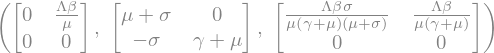

In [ ]:
seir.F, seir.V, seir.K

In [ ]:
display(Markdown(seir.report_latex("markdown")))

In [ ]:
print(seir.report_latex())

In [ ]:
print(seir.latex())

### Sensitivity indices

$\Upsilon_p = \dfrac{\partial R_0}{\partial p}\dfrac{p}{R_0}$: a 1% increase in $p$ changes $R_0$ by $\Upsilon_p$%.

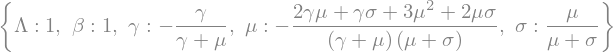

In [9]:
seir.sensitivity_indices()

In [10]:
values = {"Lambda": 10, "beta": 0.001, "sigma": 0.2, "gamma": 0.1, "mu": 0.02}
print("R0 =", seir.R0_numeric(values))
seir.sensitivity_indices(values)

R0 = 3.787878787878788


## 2. Classic SIR (closed population)

Without births the disease-free equilibrium is not unique, so the susceptible population at the DFE is given.

In [12]:
sir = R0Model({"S": "-beta*S*I/N",
               "I": "beta*S*I/N - gamma*I",
               "R": "gamma*I"}, infected=["I"], dfe={"S": "N"})
sir.R0

Without `dfe`, the error says exactly what is missing:

In [13]:
try:
    R0Model({"S": "-beta*S*I/N", "I": "beta*S*I/N - gamma*I", "R": "gamma*I"}, infected=["I"])
except Exception as e:
    print(type(e).__name__, "->", e)

DiseaseFreeEquilibriumError -> The disease-free value of ['S'] is not determined by the equations (e.g. a closed population without births). Provide it with dfe={'S': ...}.


## 3. Vector-borne disease: Ross-Macdonald model

In [ ]:
rm = R0Model("""
    dS_h/dt = L_h - a*b_h*S_h*I_v/N_h - mu_h*S_h
    dI_h/dt = a*b_h*S_h*I_v/N_h - (gamma + mu_h)*I_h
    dR_h/dt = gamma*I_h - mu_h*R_h
    dS_v/dt = L_v - a*b_v*S_v*I_h/N_h - mu_v*S_v
    dI_v/dt = a*b_v*S_v*I_h/N_h - mu_v*I_v
""", infected=["I_h", "I_v"])
rm.new_infections

In [ ]:
rm.K

In [ ]:
rm.R0

## 4. Host-vector model with human-to-human transmission and logistic vectors

The total human population is an auxiliary definition. The model has two disease-free equilibria (with and without vectors); the one with vectors is chosen and both are kept.

In [ ]:
hv = R0Model("""
    N_h = S_h + E_h + I_h + R_h
    dS_h/dt = Delta_h - delta*alpha_hv*S_h*I_v/N_h - beta*alpha_hh*S_h*I_h/N_h - (theta + mu_h)*S_h
    dE_h/dt = delta*alpha_hv*S_h*I_v/N_h + beta*alpha_hh*S_h*I_h/N_h - (sigma + mu_h)*E_h
    dI_h/dt = sigma*E_h - (gamma + mu_h)*I_h
    dR_h/dt = gamma*I_h - mu_h*R_h + theta*S_h
    dM_v/dt = phi_v*M_v*(1 - M_v/kappa_v) - (omega + mu_m)*M_v
    dS_v/dt = omega*M_v - delta*alpha_vh*S_v*I_h/N_h - (mu_v + zeta)*S_v
    dE_v/dt = delta*alpha_vh*S_v*I_h/N_h - (psi + mu_v + zeta)*E_v
    dI_v/dt = psi*E_v - (mu_v + zeta)*I_v
""", infected=["E_h", "I_h", "E_v", "I_v"])
hv.dfe

Only $E_h$ and $E_v$ receive new infections, so $R_0$ is the spectral radius of the $2\times 2$ next-generation matrix with small domain:

In [ ]:
hv.next_generation_matrix_small

In [ ]:
hv.R0

## 5. Within-host model: target cells, infected cells and virus

In [17]:
tiv = R0Model("""
    dT/dt = s - d*T - beta*T*V
    dI/dt = beta*T*V - delta*I
    dV/dt = p*I - c*V
""", infected=["I", "V"])
tiv.R0

## 6. van den Driessche & Watmough (2002), treatment model (§4.1)

$p r_2 I$ (treatment failure) is correctly classified as a transition, not a new infection.

In [ ]:
tb = R0Model("""
    N = S + E + I + T
    dE/dt = beta1*S*I/N + beta2*T*I/N - (d + nu + r1)*E + p*r2*I
    dI/dt = nu*E - (d + r2)*I
    dS/dt = b - d*S - beta1*S*I/N
    dT/dt = -d*T + r1*E + q*r2*I - beta2*T*I/N
""", infected=["E", "I"])
tb.R0

## 7. Two strains with superinfection

Which strain dominates depends on the parameters, so $R_0$ is the maximum of the strain-specific numbers.

In [ ]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    two = R0Model("""
        dI1/dt = beta1*I1*S - (b + gamma1)*I1 + nu*I1*I2
        dI2/dt = beta2*I2*S - (b + gamma2)*I2 - nu*I1*I2
        dS/dt = b - b*S + gamma1*I1 + gamma2*I2 - (beta1*I1 + beta2*I2)*S
    """, infected=["I1", "I2"])
    R0 = two.R0
R0

## 8. Your own model

Replace the equations and the infected compartments. If the automatic split into new infections and transitions is not the one you want, use `new_infections={...}`; to fix the disease-free equilibrium, use `dfe={...}`.

In [ ]:
model = R0Model("""
    dS/dt = Lambda - beta*S*I - mu*S
    dI/dt = beta*S*I - (gamma + mu)*I
""", infected=["I"])
model.R0

In [ ]:
print(model.latex())